# ASD Research: Multilayer Microbiome Feature Integration from Diagnosis to Behavioral Prediction
## Stage 2: Batch Effect Correction and Data Standardization

---

**Version**: V4.7 Revised Edition  
**Date**: February 2026  

### Goals of This Stage

1. **CLR normalization**: Apply Centered Log-Ratio transformation to all data
2. **Batch effect correction**: Use ComBat to correct the discovery cohort (7 batches)
3. **Preserve raw data**: Keep raw relative abundance for alpha-diversity analysis

### Input Data (from Stage 1)

```python
stage1_data = {
    'discovery_data_filtered': {...},  # Four-level discovery cohort data
    'moscow_data_filtered': {...},     # Four-level Moscow cohort data
    'discovery_group': Series,         # Group information
    'discovery_study': Series,         # Batch information (7 StudyIDs)
    'moscow_group': Series,            # Moscow group labels
    'local_cohort_samples': list,      # Changchun sample IDs
    'local_group': Series              # Changchun group labels
}
```

### Output Data (stage2_normalized_data.pkl)

```python
{
    'discovery_data_corrected': {...},  # Batch-corrected discovery cohort
    'discovery_data_raw': {...},        # Raw data (for alpha diversity)
    'moscow_data_clr': {...},           # Moscow CLR data
    'discovery_group': Series,          # Group information (passed through)
    'discovery_study': Series,          # Batch information (passed through)
    ...
}
```


## 2.1 Environment Setup

In [ ]:
# ============================================================
# Install required dependencies
# ============================================================
!pip install pandas numpy scipy scikit-learn matplotlib seaborn -q
!pip install combat -q  # Python版本的ComBat

print("✓ 依赖包安装完成")

  Preparing metadata (setup.py) ... done
✓ 依赖包安装完成


In [ ]:
# ============================================================
# Import required libraries
# ============================================================
import os
import pickle
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.size'] = 10
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Try importing ComBat
try:
    from combat.pycombat import pycombat
    COMBAT_AVAILABLE = True
    print("✓ ComBat (pycombat) 导入成功")
except ImportError:
    try:
        from pycombat import pycombat
        COMBAT_AVAILABLE = True
        print("✓ ComBat (pycombat) 导入成功")
    except ImportError:
        COMBAT_AVAILABLE = False
        print("⚠ ComBat 不可用，将使用备用方法")

print("✓ 库导入完成")

✓ ComBat (pycombat) 导入成功
✓ 库导入完成


In [ ]:
# ============================================================
# Mount Google Drive
# ============================================================
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
    print("✓ Google Drive 已挂载")
else:
    print("✓ Google Drive 已经挂载")

# Define paths
BASE_PATH = '/content/drive/MyDrive/ASD_Research'
DATA_PATH = os.path.join(BASE_PATH, '02_merged_data')
FIG_PATH = os.path.join(BASE_PATH, '04_figures')

Mounted at /content/drive
✓ Google Drive 已挂载


In [ ]:
# ============================================================
# Load Stage 1 output data
# ============================================================
print("=" * 60)
print("加载Stage1数据")
print("=" * 60)

stage1_path = os.path.join(DATA_PATH, 'stage1_preprocessed_data.pkl')
with open(stage1_path, 'rb') as f:
    stage1_data = pickle.load(f)

# Check the version
version = stage1_data.get('version', 'unknown')
print(f"Stage1数据版本: {version}")

# Extract data
discovery_data = stage1_data['discovery_data_filtered']
moscow_data = stage1_data['moscow_data_filtered']

discovery_group = stage1_data['discovery_group']
discovery_study = stage1_data['discovery_study']
moscow_group = stage1_data['moscow_group']

local_cohort_samples = stage1_data['local_cohort_samples']
local_group = stage1_data['local_group']

print(f"\n【数据维度】")
for dtype in ['taxa', 'pathways', 'genes', 'ecs']:
    df = discovery_data.get(dtype)
    if df is not None:
        print(f"  发现队列 {dtype}: {df.shape}")

print(f"\n【分组信息】")
print(f"  发现队列: {len(discovery_group)} 样本")
print(f"  发现队列分组: {discovery_group.value_counts().to_dict()}")
print(f"  批次数: {discovery_study.nunique()}")
print(f"  长春子队列: {len(local_cohort_samples)} 样本")
print(f"  莫斯科队列: {len(moscow_group)} 样本")

加载Stage1数据
Stage1数据版本: V4.7

【数据维度】
  发现队列 taxa: (1658, 471)
  发现队列 pathways: (433, 471)
  发现队列 genes: (37334, 471)
  发现队列 ecs: (1682, 471)

【分组信息】
  发现队列: 471 样本
  发现队列分组: {'ASD': 245, 'TD': 226}
  批次数: 7
  长春子队列: 70 样本
  莫斯科队列: 74 样本


## 2.2 CLR Transformation

In [ ]:
# ============================================================
# Define the CLR transformation function
# ============================================================
def clr_transform(df, name="data", pseudocount=1e-6):
    """
    执行Centered Log-Ratio (CLR)转换

    Parameters:
    -----------
    df : pd.DataFrame
        相对丰度数据（行为特征，列为样本）
    name : str
        数据名称（用于打印）
    pseudocount : float
        伪计数，避免log(0)

    Returns:
    --------
    pd.DataFrame : CLR转换后的数据
    """
    if df is None:
        return None

    # Add a pseudocount
    df_pseudo = df + pseudocount

    # Compute the geometric mean for each sample
    log_data = np.log(df_pseudo)
    geometric_mean = log_data.mean(axis=0)

    # CLR transformation
    clr_data = log_data - geometric_mean

    print(f"  {name}: {df.shape} → CLR完成")

    return clr_data

print("✓ CLR转换函数定义完成")

✓ CLR转换函数定义完成


In [ ]:
# ============================================================
# Run CLR transformation
# ============================================================
print("=" * 60)
print("执行CLR转换")
print("=" * 60)

# Preserve raw data (for alpha-diversity analysis)
discovery_data_raw = {}
for dtype in ['taxa', 'pathways', 'genes', 'ecs']:
    df = discovery_data.get(dtype)
    if df is not None:
        discovery_data_raw[dtype] = df.copy()

moscow_data_raw = {}
for dtype in ['taxa', 'pathways']:
    df = moscow_data.get(dtype)
    if df is not None:
        moscow_data_raw[dtype] = df.copy()

print("✓ 原始数据已保存（用于α多样性）")

# CLR transformation - discovery cohort
print("\n--- 发现队列CLR转换 ---")
discovery_data_clr = {}
for dtype in ['taxa', 'pathways', 'genes', 'ecs']:
    df = discovery_data.get(dtype)
    discovery_data_clr[dtype] = clr_transform(df, f"发现队列-{dtype}")

# CLR transformation - Moscow cohort
print("\n--- 莫斯科队列CLR转换 ---")
moscow_data_clr = {}
for dtype in ['taxa', 'pathways', 'genes', 'ecs']:
    df = moscow_data.get(dtype)
    moscow_data_clr[dtype] = clr_transform(df, f"莫斯科-{dtype}")

print("\n✓ CLR转换完成")

执行CLR转换
✓ 原始数据已保存（用于α多样性）

--- 发现队列CLR转换 ---
  发现队列-taxa: (1658, 471) → CLR完成
  发现队列-pathways: (433, 471) → CLR完成
  发现队列-genes: (37334, 471) → CLR完成
  发现队列-ecs: (1682, 471) → CLR完成

--- 莫斯科队列CLR转换 ---
  莫斯科-taxa: (2023, 74) → CLR完成
  莫斯科-pathways: (409, 74) → CLR完成
  莫斯科-genes: (34625, 74) → CLR完成
  莫斯科-ecs: (1614, 74) → CLR完成

✓ CLR转换完成


## 2.3 Batch Effect Correction

In [ ]:
# ============================================================
# 1. Install the standard neuroCombat package (if not already installed)
# ============================================================
try:
    from neuroCombat import neuroCombat
except ImportError:
    print("正在安装 neuroCombat...")
    !pip install neuroCombat
    from neuroCombat import neuroCombat

# ============================================================
# 2. Define the batch correction function based on neuroCombat (fixed version)
# ============================================================
def combat_batch_correction(data_df, batch_series, group_series=None):
    """
    使用 neuroCombat 进行批次效应校正 (行业标准方案)
    """
    if data_df is None:
        return None

    # 1. Sample alignment
    common_samples = data_df.columns.intersection(batch_series.index)
    if group_series is not None:
        common_samples = common_samples.intersection(group_series.index)

    # Ensure a consistent data order (Features x Samples)
    data_aligned = data_df[common_samples]
    batch_aligned = batch_series.loc[common_samples]

    print(f"    对齐样本数: {len(common_samples)}")
    print(f"    批次数: {batch_aligned.nunique()}")

    # 2. Prepare neuroCombat inputs
    # Data matrix (numpy array): Features x Samples
    dat = data_aligned.values

    # Covariate matrix (DataFrame): Samples x Covariates
    covars = pd.DataFrame({'batch': batch_aligned})
    categorical_cols = []

    # If a covariate (Group) is available, include it to preserve biological differences
    if group_series is not None:
        group_aligned = group_series.loc[common_samples]
        covars['group'] = group_aligned.values
        categorical_cols = ['group']

    # 3. Run neuroCombat
    try:
        # neuroCombat returns a dictionary, and 'data' is the corrected matrix
        results = neuroCombat(dat=dat,
                              covars=covars,
                              batch_col='batch',
                              categorical_cols=categorical_cols)

        corrected_data = results['data']

        # 4. Convert back to a DataFrame (preserving index and column names)
        corrected_df = pd.DataFrame(corrected_data,
                                    index=data_aligned.index,
                                    columns=data_aligned.columns)

        print(f"    ✓ neuroCombat 校正成功")
        return corrected_df

    except Exception as e:
        print(f"    ⚠ neuroCombat 失败: {str(e)}")
        # Fallback: mean correction (use only in extreme failures; neuroCombat is usually stable)
        print("    -> 正在回退到简单的均值中心化校正...")
        corrected = data_aligned.copy()
        for batch in batch_aligned.unique():
            idx = batch_aligned[batch_aligned == batch].index
            batch_mean = data_aligned[idx].mean(axis=1)
            global_mean = data_aligned.mean(axis=1)
            corrected[idx] = data_aligned[idx].subtract(batch_mean - global_mean, axis=0)
        return corrected

print("✓ 批次校正函数 (neuroCombat版) 定义完成")

正在安装 neuroCombat...
  Preparing metadata (setup.py) ... done
  Created wheel for neuroCombat: filename=neuroCombat-0.2.12-py3-none-any.whl size=6353 sha256=2290b0a1942a49fd107578efdf864b8024674d90ac2282ad6643b8cace56e5d6
  Stored in directory: /root/.cache/pip/wheels/be/6a/95/9d827c0f3cc23854b5fbd00fbc8a052d492538dc16bd20f7a2
Successfully built neuroCombat
✓ 批次校正函数 (neuroCombat版) 定义完成


In [ ]:
# ============================================================
# Apply batch correction to the discovery cohort (7 batches)
# ============================================================
print("=" * 60)
print("执行批次校正（发现队列：7个中国队列）")
print("=" * 60)
print("\n📌 说明：")
print("   - 批次变量: StudyID (7个)")
print("   - 协变量: Group (保护ASD/TD生物学差异)")
print("   - 莫斯科队列不参与批次校正")

discovery_data_corrected = {}

# Taxa
print("\n--- Taxa层面 ---")
discovery_data_corrected['taxa'] = combat_batch_correction(
    discovery_data_clr['taxa'], discovery_study, discovery_group
)

# Pathways
print("\n--- Pathways层面 ---")
discovery_data_corrected['pathways'] = combat_batch_correction(
    discovery_data_clr['pathways'], discovery_study, discovery_group
)

# Genes
print("\n--- Genes层面 ---")
discovery_data_corrected['genes'] = combat_batch_correction(
    discovery_data_clr['genes'], discovery_study, discovery_group
)

# ECs
print("\n--- ECs层面 ---")
discovery_data_corrected['ecs'] = combat_batch_correction(
    discovery_data_clr['ecs'], discovery_study, discovery_group
)

print("\n✓ 批次校正完成")

执行批次校正（发现队列：7个中国队列）

📌 说明：
   - 批次变量: StudyID (7个)
   - 协变量: Group (保护ASD/TD生物学差异)
   - 莫斯科队列不参与批次校正

--- Taxa层面 ---
    对齐样本数: 471
    批次数: 7
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
    ✓ neuroCombat 校正成功

--- Pathways层面 ---
    对齐样本数: 471
    批次数: 7
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
    ✓ neuroCombat 校正成功

--- Genes层面 ---
    对齐样本数: 471
    批次数: 7
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
    ✓ neuroCombat 校正成功

--- ECs层面 ---
    对齐样本数: 471
    批次

## 2.4 Visualize Batch Correction Effects

PCA Visualization (English Labels)


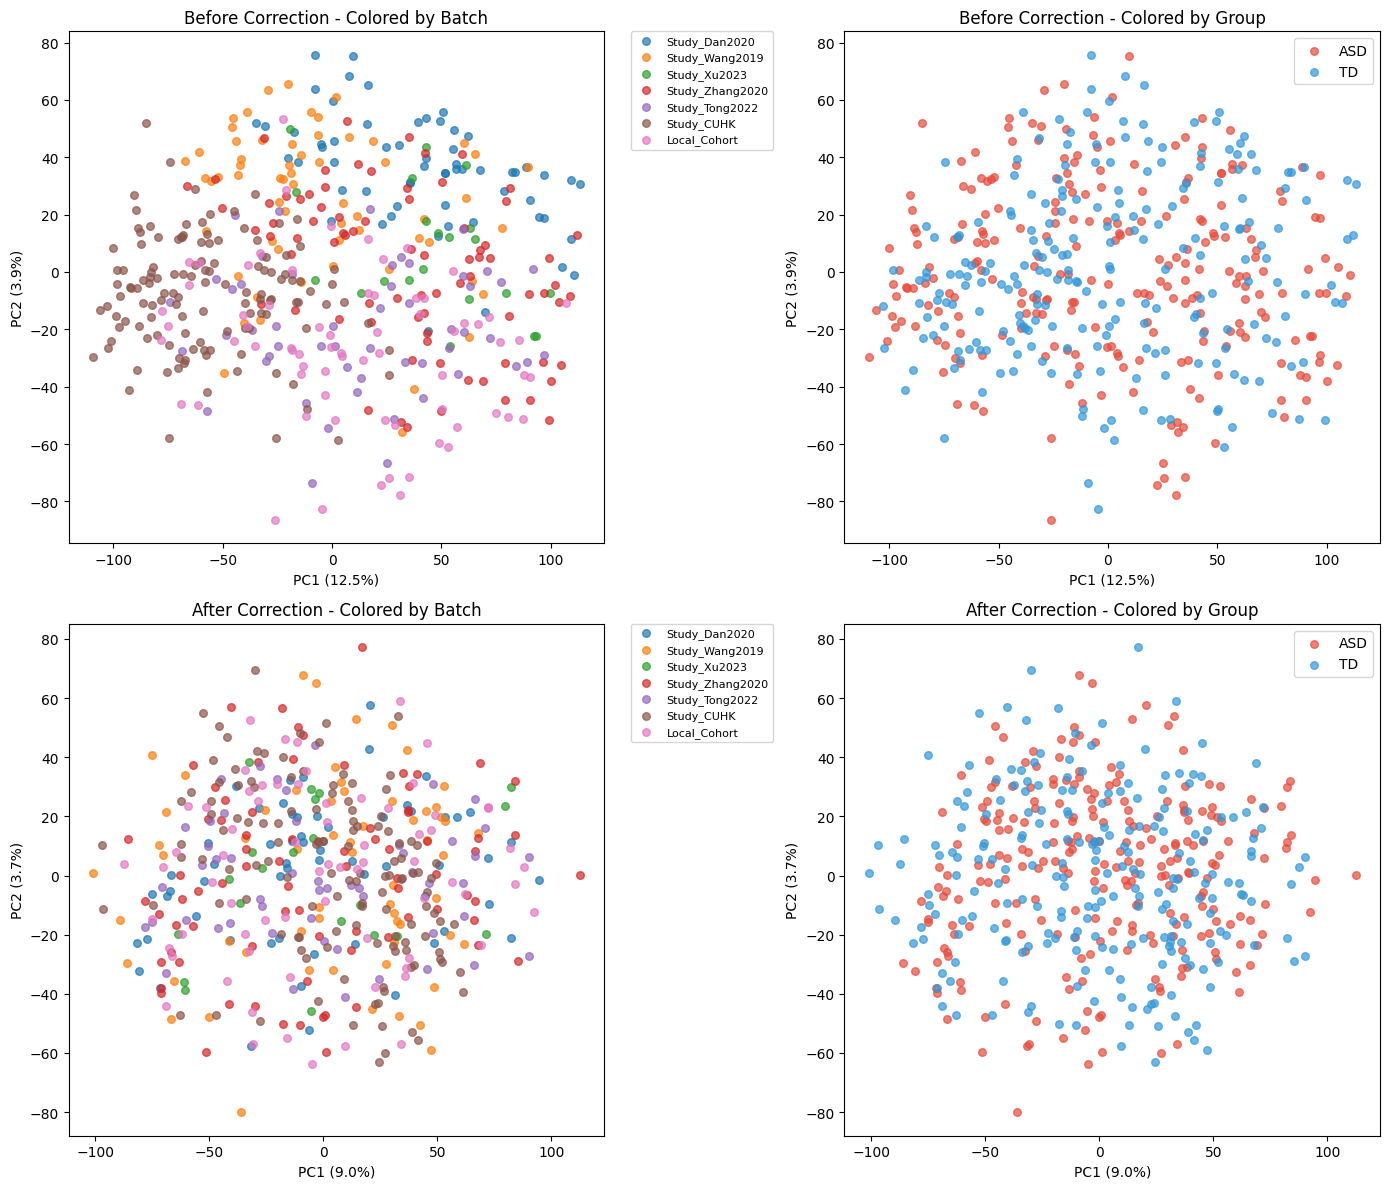


✓ PCA Figure saved (English version)


In [ ]:
# ============================================================
# PCA Visualization: Before vs After Batch Correction (English)
# ============================================================
print("=" * 60)
print("PCA Visualization (English Labels)")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Select 'taxa' level for visualization
taxa_clr = discovery_data_clr.get('taxa')
taxa_corrected = discovery_data_corrected.get('taxa')

if taxa_clr is not None and taxa_corrected is not None:
    # Ensure sample alignment
    common_samples = taxa_clr.columns.intersection(taxa_corrected.columns)
    common_samples = common_samples.intersection(discovery_study.index)
    common_samples = common_samples.intersection(discovery_group.index)

    # -------------------------------------------------------
    # 1. Before Correction - Colored by Batch (StudyID)
    # -------------------------------------------------------
    ax1 = axes[0, 0]
    X_before = taxa_clr[common_samples].T.values
    pca = PCA(n_components=2)
    X_pca_before = pca.fit_transform(X_before)

    batch_labels = discovery_study.loc[common_samples]
    # Loop through batches to plot
    for batch in batch_labels.unique():
        mask = batch_labels == batch
        ax1.scatter(X_pca_before[mask, 0], X_pca_before[mask, 1],
                   label=batch, alpha=0.7, s=30)

    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax1.set_title('Before Correction - Colored by Batch') # English Title
    # Move legend outside to prevent blocking points
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, borderaxespad=0.)

    # -------------------------------------------------------
    # 2. Before Correction - Colored by Group (ASD/TD)
    # -------------------------------------------------------
    ax2 = axes[0, 1]
    group_labels = discovery_group.loc[common_samples]
    colors = {'ASD': '#E74C3C', 'TD': '#3498DB'}

    for group in ['ASD', 'TD']:
        mask = group_labels == group
        ax2.scatter(X_pca_before[mask, 0], X_pca_before[mask, 1],
                   c=colors[group], label=group, alpha=0.7, s=30)

    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax2.set_title('Before Correction - Colored by Group') # English Title
    ax2.legend(loc='upper right')

    # -------------------------------------------------------
    # 3. After Correction - Colored by Batch (StudyID)
    # -------------------------------------------------------
    ax3 = axes[1, 0]
    X_after = taxa_corrected[common_samples].T.values
    X_pca_after = pca.fit_transform(X_after)

    for batch in batch_labels.unique():
        mask = batch_labels == batch
        ax3.scatter(X_pca_after[mask, 0], X_pca_after[mask, 1],
                   label=batch, alpha=0.7, s=30)

    ax3.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax3.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax3.set_title('After Correction - Colored by Batch') # English Title
    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, borderaxespad=0.)

    # -------------------------------------------------------
    # 4. After Correction - Colored by Group (ASD/TD)
    # -------------------------------------------------------
    ax4 = axes[1, 1]
    for group in ['ASD', 'TD']:
        mask = group_labels == group
        ax4.scatter(X_pca_after[mask, 0], X_pca_after[mask, 1],
                   c=colors[group], label=group, alpha=0.7, s=30)

    ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax4.set_title('After Correction - Colored by Group') # English Title
    ax4.legend(loc='upper right')

plt.tight_layout()
# Save figures
plt.savefig(os.path.join(FIG_PATH, 'Fig_S1_BatchCorrection_PCA.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(FIG_PATH, 'Fig_S1_BatchCorrection_PCA.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ PCA Figure saved (English version)")

## 2.5 Save Stage 2 Output Data

In [ ]:
# ============================================================
# Save Stage 2 output data
# ============================================================
print("=" * 60)
print("保存Stage2输出数据")
print("=" * 60)

stage2_output = {
    # ==== Discovery cohort data (after batch correction) ====
    'discovery_data_corrected': discovery_data_corrected,

    # ==== Discovery cohort raw data (for alpha diversity) ====
    'discovery_data_raw': discovery_data_raw,

    # ==== Discovery cohort CLR data (before batch correction) ====
    'discovery_data_clr': discovery_data_clr,

    # ==== External validation cohort (Moscow, CLR only) ====
    'moscow_data_clr': moscow_data_clr,

    # ==== Moscow raw data ====
    'moscow_data_raw': moscow_data_raw,

    # ==== Metadata (passed from Stage 1) ====
    'discovery_group': discovery_group,
    'discovery_study': discovery_study,
    'moscow_group': moscow_group,
    'local_cohort_samples': local_cohort_samples,
    'local_group': local_group,

    # ==== Version information ====
    'version': 'V4.7',
    'description': '发现队列批次校正后 + 莫斯科队列CLR'
}

# Save
output_path = os.path.join(DATA_PATH, 'stage2_normalized_data.pkl')
with open(output_path, 'wb') as f:
    pickle.dump(stage2_output, f)

print(f"✓ 数据已保存至: {output_path}")

# Verify
print("\n【输出数据验证】")
for key in ['discovery_data_corrected', 'discovery_data_raw', 'moscow_data_clr',
            'discovery_group', 'discovery_study', 'moscow_group',
            'local_cohort_samples', 'local_group']:
    value = stage2_output.get(key)
    if isinstance(value, dict):
        print(f"  ✓ {key}: dict")
        for k, v in value.items():
            if v is not None and hasattr(v, 'shape'):
                print(f"      - {k}: {v.shape}")
    elif isinstance(value, pd.Series):
        print(f"  ✓ {key}: Series, len={len(value)}")
    elif isinstance(value, list):
        print(f"  ✓ {key}: list, len={len(value)}")
    else:
        print(f"  ✓ {key}: {type(value).__name__}")

保存Stage2输出数据
✓ 数据已保存至: /content/drive/MyDrive/ASD_Research/02_merged_data/stage2_normalized_data.pkl

【输出数据验证】
  ✓ discovery_data_corrected: dict
      - taxa: (1658, 471)
      - pathways: (433, 471)
      - genes: (37334, 471)
      - ecs: (1682, 471)
  ✓ discovery_data_raw: dict
      - taxa: (1658, 471)
      - pathways: (433, 471)
      - genes: (37334, 471)
      - ecs: (1682, 471)
  ✓ moscow_data_clr: dict
      - taxa: (2023, 74)
      - pathways: (409, 74)
      - genes: (34625, 74)
      - ecs: (1614, 74)
  ✓ discovery_group: Series, len=471
  ✓ discovery_study: Series, len=471
  ✓ moscow_group: Series, len=74
  ✓ local_cohort_samples: list, len=70
  ✓ local_group: Series, len=70


In [ ]:
# ============================================================
# Stage 2 summary report
# ============================================================
print("\n" + "=" * 60)
print("Stage2：批次效应校正与数据标准化 - 完成！")
print("=" * 60)

print("""
┌─────────────────────────────────────────────────────────────────┐
│                    Stage2 处理汇总 (V4.7)                        │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  【数据标准化】                                                  │
│  • 方法: CLR (Centered Log-Ratio) 转换                         │
│  • 伪计数: 1e-6                                                 │
│                                                                 │
│  【批次效应校正】                                                │
│  • 方法: ComBat                                                 │
│  • 发现队列: 7个批次校正                                        │
│  • 协变量: Group (保护ASD/TD差异)                              │
│  • 莫斯科队列: 不参与校正                                       │
│                                                                 │
│  【输出变量】供Stage3-5使用                                      │
│  • discovery_data_corrected: 批次校正后数据                     │
│  • discovery_data_raw: 原始数据（α多样性用）                    │
│  • moscow_data_clr: 莫斯科CLR数据                              │
│  • discovery_group/study: 分组和批次信息                        │
│  • local_cohort_samples: 长春样本ID                            │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
""")

# Data statistics
if discovery_data_corrected.get('taxa') is not None:
    print(f"发现队列样本数: {discovery_data_corrected['taxa'].shape[1]}")
if moscow_data_clr.get('taxa') is not None:
    print(f"莫斯科队列样本数: {moscow_data_clr['taxa'].shape[1]}")

print("\n" + "=" * 60)
print("✓ Stage2完成，请继续执行Stage3")
print("=" * 60)


Stage2：批次效应校正与数据标准化 - 完成！

┌─────────────────────────────────────────────────────────────────┐
│                    Stage2 处理汇总 (V4.7)                        │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  【数据标准化】                                                  │
│  • 方法: CLR (Centered Log-Ratio) 转换                         │
│  • 伪计数: 1e-6                                                 │
│                                                                 │
│  【批次效应校正】                                                │
│  • 方法: ComBat                                                 │
│  • 发现队列: 7个批次校正                                        │
│  • 协变量: Group (保护ASD/TD差异)                              │
│  • 莫斯科队列: 不参与校正                                       │
│                                                                 │
│  【输出变量】供Stage3-5使用                                      │
│  • discover